# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 6. Компьютерное зрение & генеративные модели


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание:**

* Задача 1 &mdash; 120 баллов
* Задача 2 &mdash; 80 баллов
* Задача 3 &mdash; 30 баллов

In [2]:
# Bot check

# HW_ID: fpmi_ad6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [3]:
import time

import warnings
from typing import Union
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from collections import defaultdict
from typing import Callable, Dict, List, Tuple, Optional, Union
from torchinfo import summary
from IPython.display import clear_output

from torch.utils.data import DataLoader

sns.set(font_scale=1, style="darkgrid", palette="Set2")
warnings.simplefilter("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


Перед выполнением задания обязательно посмотрите <a href="https://thetahat.ru/files/ad/main/7/CV_intro no_pause.pdf" target="_blank">презентацию</a> и <a href="https://thetahat.ru/courses/ad/main/7/cv_classification" target="_blank">ноутбук</a> про сверточные сети и классификацию, а так же <a href="https://thetahat.ru/files/ad/main/7/CV_complex_no_pause.pdf" target="_blank">презентацию</a> и <a href="https://thetahat.ru/courses/ad/main/7/cv_complex_examples" target="_blank">ноутбук</a> про перенос стиля и генеративные сети. 

&#x2757; **Весь код работы с библиотекой PyTorch необходимо написать самостоятельно, без использования ИИ-инструментов.** Но можно использовать код из ноутбуков, рассказанных на занятии. Можно использовать ИИ-инструменты для написания технического кода (например, построение графиков), оформления ранее написанного кода и в качестве справки. Выводы необходимо делать самостоятельно.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### Задача 1. Классификация MNIST


В данной задаче вам нужно провести сравнительный анализ сверточных нейросетей с различными параметрами на датасета рукописных цифр MNIST. С этим датасетом вы уже познакомились в <a href="https://thetahat.ru/courses/ad/main/6/vvad_hw5">предыдущем задании</a>. Классификация в MNIST значительно проще, чем в CIFAR, рассмотренном на <a href="https://thetahat.ru/courses/ad/main/7/cv_classification" target="_blank">занятии</a>, поэтому ваша задача — достичь **на валидации** хотя бы одной из моделей точности 97%. Вы можете свободно использовать код с занятия.

> Использования слоев с семинара (свертка, pooling) более чем достаточно для достижения 97% точности на тесте. Также не делайте сеть глубокой.

> Тестируйте работоспособность кода на CPU с небольшим количеством итераций. Если все работает, и хочется ускорить процесс, переходите на GPU.

Следуйте указаниям ниже.

**1.** Загрузим датаcет из `torchvision.datasets`.

In [4]:
# Данные для обучения
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
# Данные для тестирования
val_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor()
)
# Классы объектов в датасете
num_classes = 10
classes_list = [str(i) for i in range(num_classes)]

Создайте генераторы батчей.

In [5]:
batch_size = 64  # размер батча

train_batch_gen = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_batch_gen = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

**2.** Создайте хотя бы 5 сверточных нейросетей с разным количеством линейных и сверточных слоев. Должен присутствовать хотя бы 1 сверточный слой и хотя бы 1 линейный слой. Для каждой посмотрите количество параметров с помощью `torchinfo.summary`. Никакие специальные слои, которые мы не изучали, использовать не нужно.

In [27]:
def plot_histories(histories: List[Dict[str, Dict[str, list]]], names: List[str]) -> None:
    """
    Визуализирует лосс и точность для нескольких моделей на одном графике.

    Параметры:
        histories (List[Dict[str, Dict[str, list]]]): Список историй обучения моделей.
            Каждая история должна содержать ключи "loss" и "acc" с подключами "train" и "val".
        names (List[str]): Список названий моделей для легенды.

    Возвращает:
        None
    """
    # Устанавливаем стиль "darkgrid" только для текущего графика
    with sns.axes_style("darkgrid"):
        # Цвета для графиков
        colors = ["darkblue", "lightcoral", "limegreen", "sandybrown", "red", "black"]

        # Создаем фигуру с двумя подграфиками
        fig, axs = plt.subplots(1, 2, figsize=(16, 8))

        # Определяем количество эпох для отображения (минимальное среди всех историй)
        epochs = np.min([len(h["loss"]["train"]) for h in histories])

        # Построение графиков для каждой модели
        for i, (history, name) in enumerate(zip(histories, names)):
            # График лосса
            axs[0].set_title("Лосс")
            axs[0].plot(
                history["loss"]["train"][:epochs],
                label=f"{name}",
                lw=2,
                c=colors[i],
                ls="--",
            )
            axs[0].plot(
                history["loss"]["val"][:epochs],
                lw=1.5,
                c=colors[i],
            )
            axs[0].set_xlabel("Номер эпохи")
            axs[0].set_xscale("log")

            # График точности
            axs[1].set_title("Точность классификации")
            axs[1].plot(
                history["acc"]["train"][:epochs], label=f"{name}", lw=2, c=colors[i], ls="--"
            )
            axs[1].plot(history["acc"]["val"][:epochs], lw=1.5, c=colors[i])
            axs[1].set_xlabel("Номер эпохи")
            axs[1].set_xscale("log")
            axs[1].legend()

        # Создаем фиктивные линии для легенды (train и val)
        dummy_lines = [
            axs[0].plot([], [], c="black", lw=2, ls="--")[0],
            axs[0].plot([], [], c="black", lw=1.5)[0],
        ]

        # Добавляем легенду для типов линий (train и val)
        for i in range(2):
            legend = axs[i].legend(loc=3 - i)  # Легенда для моделей
            axs[i].legend(dummy_lines, ["train", "val"], loc=4)  # Легенда для типов линий
            axs[i].add_artist(legend)  # Добавляем обе легенды на график

            
        plt.show()


def print_epoch(epoch, num_epochs, history, t):
    """
    Функция для вывода информации про эпоху.
    :param epoch: номер эпохи
    :param num_epochs: общее количество эпох
    :param history: (dict) accuracy и loss на обучении и валидации ("история" обучения)
    :param t: время эпохи в секундах
    """
    clear_output(wait=True)
    print("Эпоха {} из {}, затраченное время {:.3f} сек.".format(epoch + 1, num_epochs, t))
    print("  лосс на обучении: \t{:.6f}".format(history["loss"]["train"][-1]))
    print("  лосс на валидации: \t{:.6f}".format(history["loss"]["val"][-1]))
    print("  точность на обучении: \t\t{:.2f} %".format(history["acc"]["train"][-1] * 100))
    print("  точность на валидации: \t\t{:.2f} %".format(history["acc"]["val"][-1] * 100))

    # Строим графики лосса и точности
    plot_histories([history], ["Model"])


def update_history(
    history: Dict[str, Dict[str, list]], loss: float, acc: float, num_batches: int, mode: str
) -> None:
    """
    Обновляет историю обучения, добавляя в нее loss и accuracy для текущей эпохи.

    Параметры:
        history (Dict[str, Dict[str, list]]): Словарь с историей обучения.
        loss (float): Суммарный loss за эпоху.
        acc (float): Суммарная точность за эпоху.
        num_batches (int): Количество батчей в эпохе.
        mode (str): Режим обучения ("train" или "val").
    """
    # Нормализуем loss и accuracy по количеству батчей
    loss /= num_batches
    acc /= num_batches
    history["loss"][mode].append(loss)
    history["acc"][mode].append(acc)


def get_batch_loss(
    X_batch: torch.Tensor,
    y_batch: torch.Tensor,
    model: nn.Module,
    criterion: Callable,
    current_loss: float,
    current_acc: float,
) -> Tuple[torch.Tensor, float, float]:
    """
    Вычисляет loss и accuracy для одного батча (без backward pass).

    Параметры:
        X_batch (torch.Tensor): Батч входных данных.
        y_batch (torch.Tensor): Батч меток.
        model (nn.Module): Модель для обучения (выдает логиты).
        criterion (Callable): Функция потерь.
        current_loss (float): Текущий лосс за батч.
        current_acc (float): Текущая точность за батч.

    Возвращает:
        Tuple[torch.Tensor, float, float]: Лосс на батче, обновленные суммарные loss и accuracy.
    """
    # Перемещаем данные на устройство (GPU/CPU)
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # Получаем логиты от модели
    logits = model(X_batch)

    # Вычисляем loss
    loss = criterion(logits, y_batch.long().to(device))

    # Сохраняем лоссы и точность
    current_loss += loss.detach().cpu().numpy()
    y_pred = logits.max(1)[1].detach().cpu().numpy()
    current_acc += np.mean(y_batch.cpu().numpy() == y_pred)
    return loss, current_loss, current_acc


def train(
    model: nn.Module,
    criterion: Callable,
    optimizer: optim.Optimizer,
    train_batch_gen: DataLoader,
    val_batch_gen: DataLoader,
    num_epochs: int = 40,
) -> Dict[str, Dict[str, list]]:
    """
    Обучает модель и возвращает историю обучения.

    Параметры:
        model (nn.Module): Модель для обучения.
        criterion (Callable): Функция потерь.
        optimizer (optim.Optimizer): Оптимизатор.
        train_batch_gen (DataLoader): Генератор батчей для обучения.
        val_batch_gen (DataLoader): Генератор батчей для валидации.
        num_epochs (int): Количество эпох (по умолчанию 40).

    Возвращает:
        Dict[str, Dict[str, list]]: История обучения, содержащая loss и accuracy для обучения и валидации.
    """
    history = defaultdict(lambda: defaultdict(list))

    for epoch in range(num_epochs):
        train_loss, val_loss = 0, 0
        train_acc, val_acc = 0, 0
        start_time = time.time()

        # ----------------------   ОБУЧЕНИЕ   ----------------------#
        model.train(True)

        # На каждой "эпохе" делаем полный проход по данным
        for X_batch, y_batch in train_batch_gen:

            # Вычисляем loss и accuracy для батча
            loss, train_loss, train_acc = get_batch_loss(
                X_batch, y_batch, model, criterion, train_loss, train_acc
            )

            # Обратный проход, вычисление градиентов
            loss.backward()
            # Шаг градиентного спуска для обновления оценок весов
            optimizer.step()
            # Зануление градиентов
            optimizer.zero_grad()

        # Обновляем историю обучения
        update_history(history, train_loss, train_acc, len(train_batch_gen), "train")

        # ----------------------   ВАЛИДАЦИЯ   ----------------------#
        model.train(False)

        # Контекстный менеджер, отключающий подсчет градиентов
        with torch.no_grad():
            # Полный проход по валидационному датасету
            for X_batch, y_batch in val_batch_gen:
                # Вычисляем loss и accuracy для батча
                _, val_loss, val_acc = get_batch_loss(
                    X_batch, y_batch, model, criterion, val_loss, val_acc
                )

        # Обновляем историю валидации
        update_history(history, val_loss, val_acc, len(val_batch_gen), "val")

        # Выводим информацию о текущей эпохе
        print_epoch(epoch, num_epochs, history, time.time() - start_time)

    return history

In [28]:
cnn_1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=5408, out_features=10),
).to(device)

summary(cnn_1, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Flatten: 1-4                           [1, 5408]                 --
├─Linear: 1-5                            [1, 10]                   54,090
Total params: 54,410
Trainable params: 54,410
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.27
Input size (MB): 0.00
Forward/backward pass size (MB): 0.17
Params size (MB): 0.22
Estimated Total Size (MB): 0.39

In [29]:
cnn_2 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=3872, out_features=10),
).to(device)

summary(cnn_2, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 32, 11, 11]           9,248
├─ReLU: 1-5                              [1, 32, 11, 11]           --
├─Flatten: 1-6                           [1, 3872]                 --
├─Linear: 1-7                            [1, 10]                   38,730
Total params: 48,298
Trainable params: 48,298
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.37
Input size (MB): 0.00
Forward/backward pass size (MB): 0.20
Params size (MB): 0.19
Estimated Total Size (MB): 0.40

In [30]:
cnn_3 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=3872, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10),
).to(device)

summary(cnn_3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 32, 11, 11]           9,248
├─ReLU: 1-5                              [1, 32, 11, 11]           --
├─Flatten: 1-6                           [1, 3872]                 --
├─Linear: 1-7                            [1, 128]                  495,744
├─ReLU: 1-8                              [1, 128]                  --
├─Linear: 1-9                            [1, 10]                   1,290
Total params: 506,602
Trainable params: 506,602
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.21
Params size (MB): 2.03
Estimated Total Si

In [31]:
cnn_4 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(cnn_4, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 32, 11, 11]           9,248
├─ReLU: 1-5                              [1, 32, 11, 11]           --
├─Conv2d: 1-6                            [1, 32, 9, 9]             9,248
├─ReLU: 1-7                              [1, 32, 9, 9]             --
├─MaxPool2d: 1-8                         [1, 32, 4, 4]             --
├─Flatten: 1-9                           [1, 512]                  --
├─Linear: 1-10                           [1, 10]                   5,130
Total params: 23,946
Trainable params: 23,946
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.09
Input size (MB): 0.00
Forward/backw

In [32]:
cnn_5 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10),
).to(device)

summary(cnn_5, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 32, 11, 11]           9,248
├─ReLU: 1-5                              [1, 32, 11, 11]           --
├─Conv2d: 1-6                            [1, 32, 9, 9]             9,248
├─ReLU: 1-7                              [1, 32, 9, 9]             --
├─MaxPool2d: 1-8                         [1, 32, 4, 4]             --
├─Flatten: 1-9                           [1, 512]                  --
├─Linear: 1-10                           [1, 128]                  65,664
├─ReLU: 1-11                             [1, 128]                  --
├─Linear: 1-12                           [1, 10]                   1,290
T

Обучите сети, используя функцию потерь `nn.CrossEntropyLoss` и оптимизатор `torch.optim.SGD` с дефолтными параметрами.

Эпоха 40 из 40, затраченное время 5.390 сек.
  лосс на обучении: 	0.239084
  лосс на валидации: 	0.226875
  точность на обучении: 		93.23 %
  точность на валидации: 		93.70 %


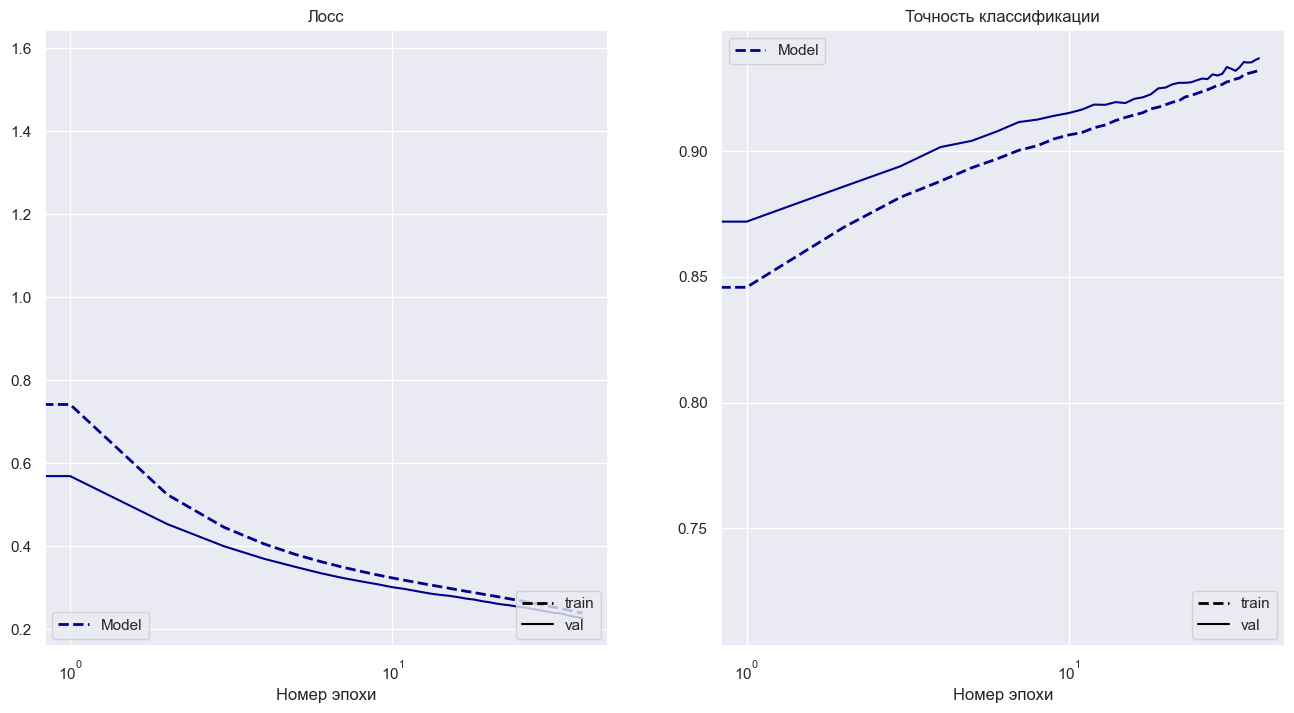

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_1.parameters())

history_cnn_1 = train(cnn_1, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_1.state_dict(), "cnn_1.pth")

Эпоха 40 из 40, затраченное время 9.286 сек.
  лосс на обучении: 	0.158304
  лосс на валидации: 	0.145761
  точность на обучении: 		95.53 %
  точность на валидации: 		95.92 %


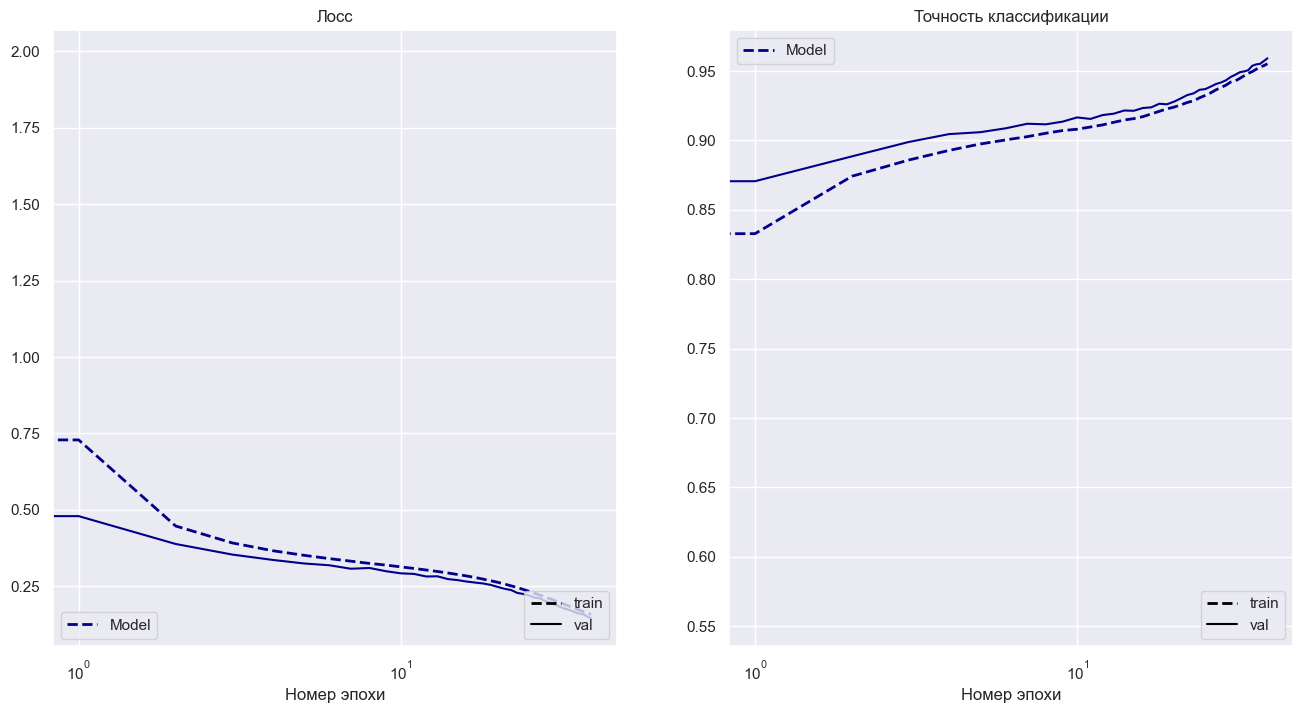

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_2.parameters())

history_cnn_2 = train(cnn_2, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_2.state_dict(), "cnn_2.pth")

Эпоха 40 из 40, затраченное время 10.305 сек.
  лосс на обучении: 	0.120461
  лосс на валидации: 	0.114475
  точность на обучении: 		96.37 %
  точность на валидации: 		96.73 %


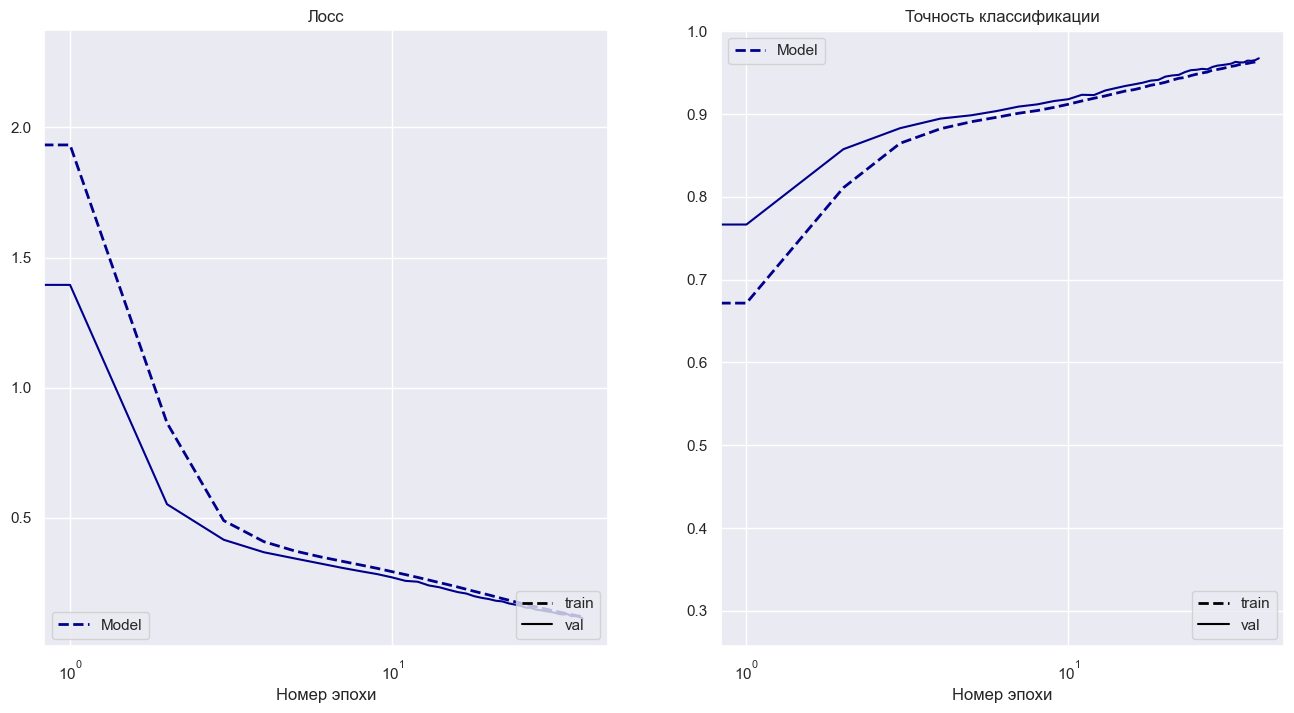

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_3.parameters())

history_cnn_3 = train(cnn_3, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_3.state_dict(), "cnn_3.pth")

Эпоха 40 из 40, затраченное время 13.575 сек.
  лосс на обучении: 	0.106331
  лосс на валидации: 	0.095134
  точность на обучении: 		96.73 %
  точность на валидации: 		97.26 %


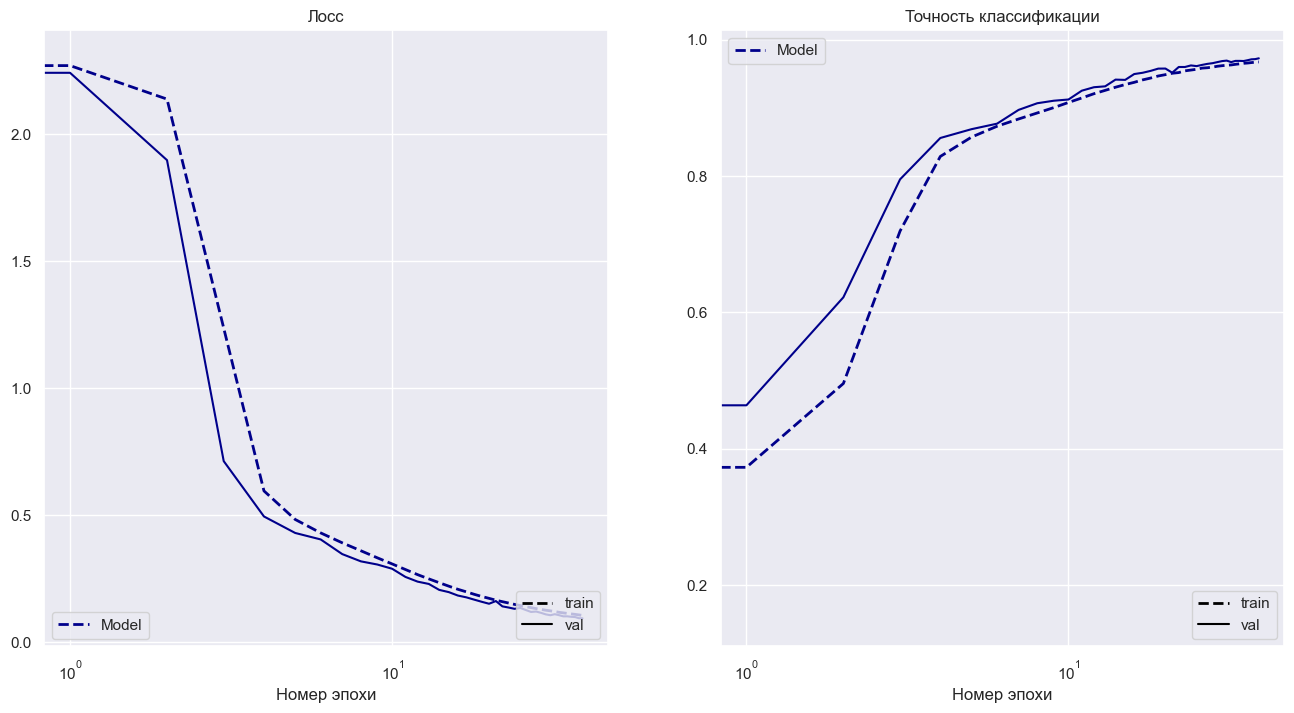

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_4.parameters())

history_cnn_4 = train(cnn_4, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_4.state_dict(), "cnn_4.pth")

Эпоха 40 из 40, затраченное время 13.676 сек.
  лосс на обучении: 	0.110096
  лосс на валидации: 	0.110924
  точность на обучении: 		96.68 %
  точность на валидации: 		96.55 %


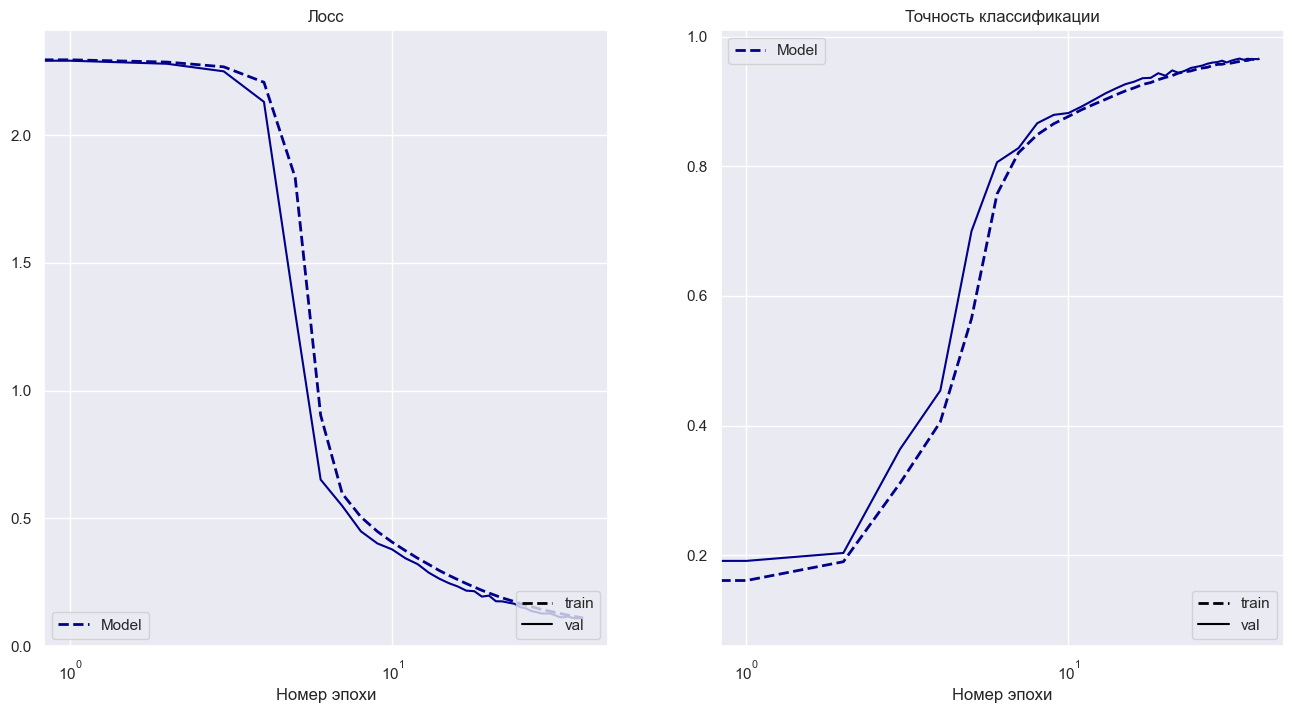

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_5.parameters())

history_cnn_5 = train(cnn_5, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_5.state_dict(), "cnn_5.pth")

In [38]:
cnn_6 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(cnn_6, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─Conv2d: 1-3                            [1, 32, 24, 24]           9,248
├─ReLU: 1-4                              [1, 32, 24, 24]           --
├─MaxPool2d: 1-5                         [1, 32, 12, 12]           --
├─Conv2d: 1-6                            [1, 32, 10, 10]           9,248
├─ReLU: 1-7                              [1, 32, 10, 10]           --
├─Conv2d: 1-8                            [1, 32, 8, 8]             9,248
├─ReLU: 1-9                              [1, 32, 8, 8]             --
├─MaxPool2d: 1-10                        [1, 32, 4, 4]             --
├─Flatten: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 10]                   5,130
To

Эпоха 26 из 40, затраченное время 24.778 сек.
  лосс на обучении: 	0.108172
  лосс на валидации: 	0.096547
  точность на обучении: 		96.72 %
  точность на валидации: 		96.92 %


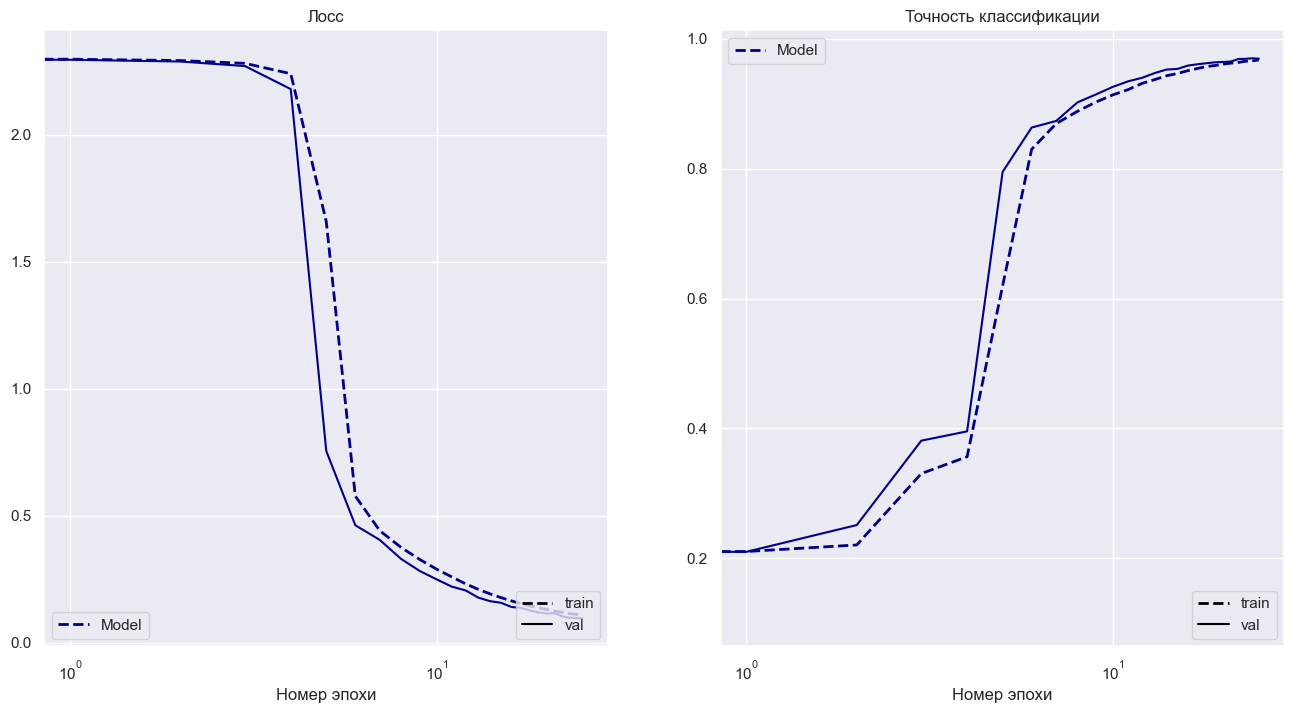

KeyboardInterrupt: 

In [39]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn_6.parameters())

history_cnn_6 = train(cnn_6, criterion, optimizer, train_batch_gen, val_batch_gen)
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(cnn_6.state_dict(), "cnn_6.pth")

Постройте график лосса и график accuracy, где сравниваются все модели (на train и на val). Нужная функция есть в семинаре.

In [ ]:
histories = [history_cnn_1, history_cnn_2, history_cnn_3, history_cnn_4, history_cnn_5, history_cnn_6]
plot_histories(histories, ['1+1', '2+1', '2+2', '3+1', '3+2', '4+1'])

In [ ]:
print(history_cnn_1[-1], history_cnn_2[-1], history_cnn_3[-1], history_cnn_4[-1], history_cnn_5[-1], history_cnn_6[-1])

Сделайте вывод. Как количество разных слоев влияет на качество и время обучения?

**Вывод по эксперименту:**

Количество сверточных слоев сильно увеличивает время обучения. Линейных - не так сильно. В результатах нашего эксперимента получили точную положительную зависимость - чем больше сверточных слоев, тем больше точность предсказания. С линейными слоями ситуация более сложная. При малом кол-ве сверточных слоев второй линейный слой дает выйгрыш. Но при достаточном кол-ве сверточных слоев он делает точность хуже

Получили что оптимальная конфигурация


4 сверточных слоя с ReLu


1 линейный слой


**3.** Теперь выберите лучший вариант, зафиксируйте это количество сверточных и линейных слоев и обучите 4 сверточных нейросети, варьируя размеры ядер сверток всех сверточных слоев нейросети: 3x3, 5x5, 7x7, 9x9.

Добавим в модели padding, т.к. без него на лучшей нейронной сети не получается запуститься (вход меньше фильтра)

In [141]:
best_3 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(best_3, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─Conv2d: 1-3                            [1, 32, 24, 24]           9,248
├─ReLU: 1-4                              [1, 32, 24, 24]           --
├─MaxPool2d: 1-5                         [1, 32, 12, 12]           --
├─Conv2d: 1-6                            [1, 32, 10, 10]           9,248
├─ReLU: 1-7                              [1, 32, 10, 10]           --
├─Conv2d: 1-8                            [1, 32, 8, 8]             9,248
├─ReLU: 1-9                              [1, 32, 8, 8]             --
├─MaxPool2d: 1-10                        [1, 32, 4, 4]             --
├─Flatten: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 10]                   5,130
To

In [148]:
best_5 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(best_5, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           832
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─Conv2d: 1-3                            [1, 32, 24, 24]           25,632
├─ReLU: 1-4                              [1, 32, 24, 24]           --
├─MaxPool2d: 1-5                         [1, 32, 12, 12]           --
├─Conv2d: 1-6                            [1, 32, 10, 10]           25,632
├─ReLU: 1-7                              [1, 32, 10, 10]           --
├─Conv2d: 1-8                            [1, 32, 8, 8]             25,632
├─ReLU: 1-9                              [1, 32, 8, 8]             --
├─MaxPool2d: 1-10                        [1, 32, 4, 4]             --
├─Flatten: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 10]                   5,130

In [149]:
best_7 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=7, padding=2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=2),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(best_7, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           1,600
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─Conv2d: 1-3                            [1, 32, 24, 24]           50,208
├─ReLU: 1-4                              [1, 32, 24, 24]           --
├─MaxPool2d: 1-5                         [1, 32, 12, 12]           --
├─Conv2d: 1-6                            [1, 32, 10, 10]           50,208
├─ReLU: 1-7                              [1, 32, 10, 10]           --
├─Conv2d: 1-8                            [1, 32, 8, 8]             50,208
├─ReLU: 1-9                              [1, 32, 8, 8]             --
├─MaxPool2d: 1-10                        [1, 32, 4, 4]             --
├─Flatten: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 10]                   5,1

In [150]:
best_9 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=9, padding=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=9, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=9, padding=3),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=9, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=10),
).to(device)

summary(best_9, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           2,624
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─Conv2d: 1-3                            [1, 32, 24, 24]           82,976
├─ReLU: 1-4                              [1, 32, 24, 24]           --
├─MaxPool2d: 1-5                         [1, 32, 12, 12]           --
├─Conv2d: 1-6                            [1, 32, 10, 10]           82,976
├─ReLU: 1-7                              [1, 32, 10, 10]           --
├─Conv2d: 1-8                            [1, 32, 8, 8]             82,976
├─ReLU: 1-9                              [1, 32, 8, 8]             --
├─MaxPool2d: 1-10                        [1, 32, 4, 4]             --
├─Flatten: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 10]                   5,1

In [146]:
histories_ker = []

Эпоха 40 из 40, затраченное время 27.003 сек.
  лосс на обучении: 	0.077836
  лосс на валидации: 	0.071839
  точность на обучении: 		97.71 %
  точность на валидации: 		97.71 %


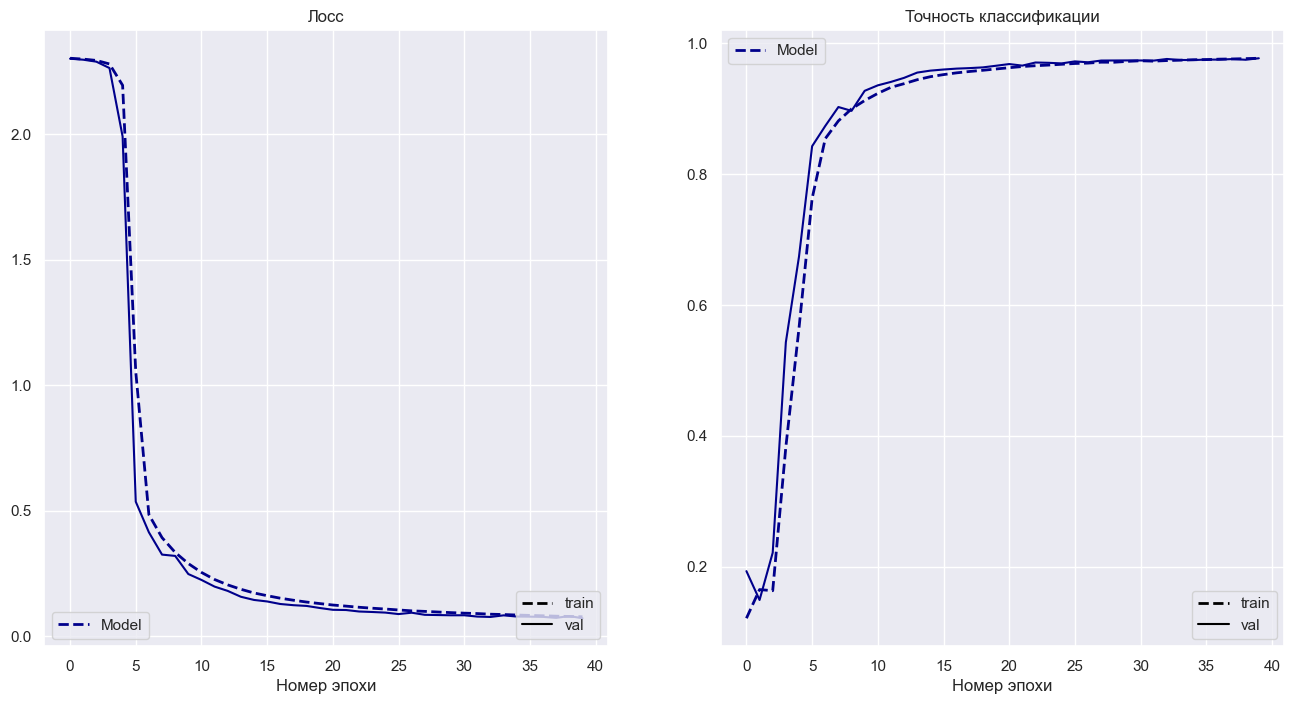

In [147]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(best_3.parameters())


histories_ker.append(train(best_3, criterion, optimizer, train_batch_gen, val_batch_gen))
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(best_3.state_dict(), "best_3.pth")

Эпоха 40 из 40, затраченное время 46.664 сек.
  лосс на обучении: 	0.060358
  лосс на валидации: 	0.059676
  точность на обучении: 		98.14 %
  точность на валидации: 		98.10 %


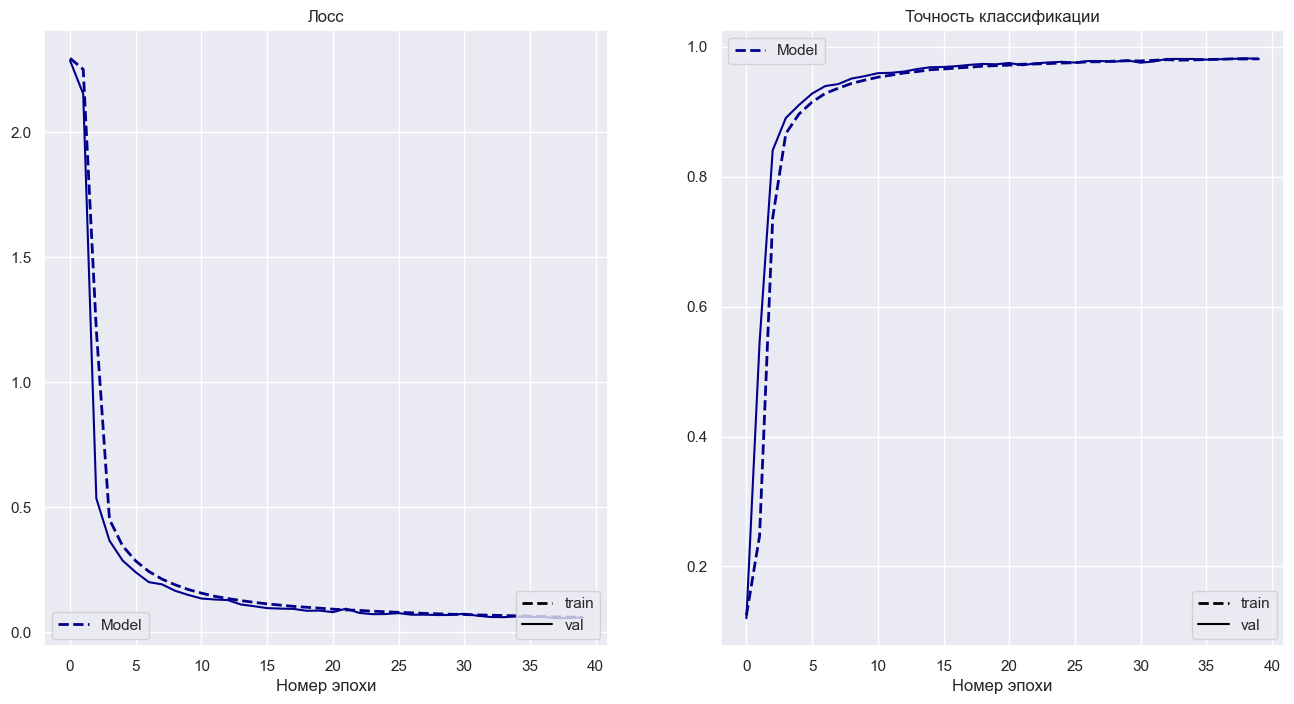

In [151]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(best_5.parameters())


histories_ker.append(train(best_5, criterion, optimizer, train_batch_gen, val_batch_gen))
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(best_5.state_dict(), "best_5.pth")

Эпоха 40 из 40, затраченное время 95.097 сек.
  лосс на обучении: 	0.036275
  лосс на валидации: 	0.044620
  точность на обучении: 		98.86 %
  точность на валидации: 		98.55 %


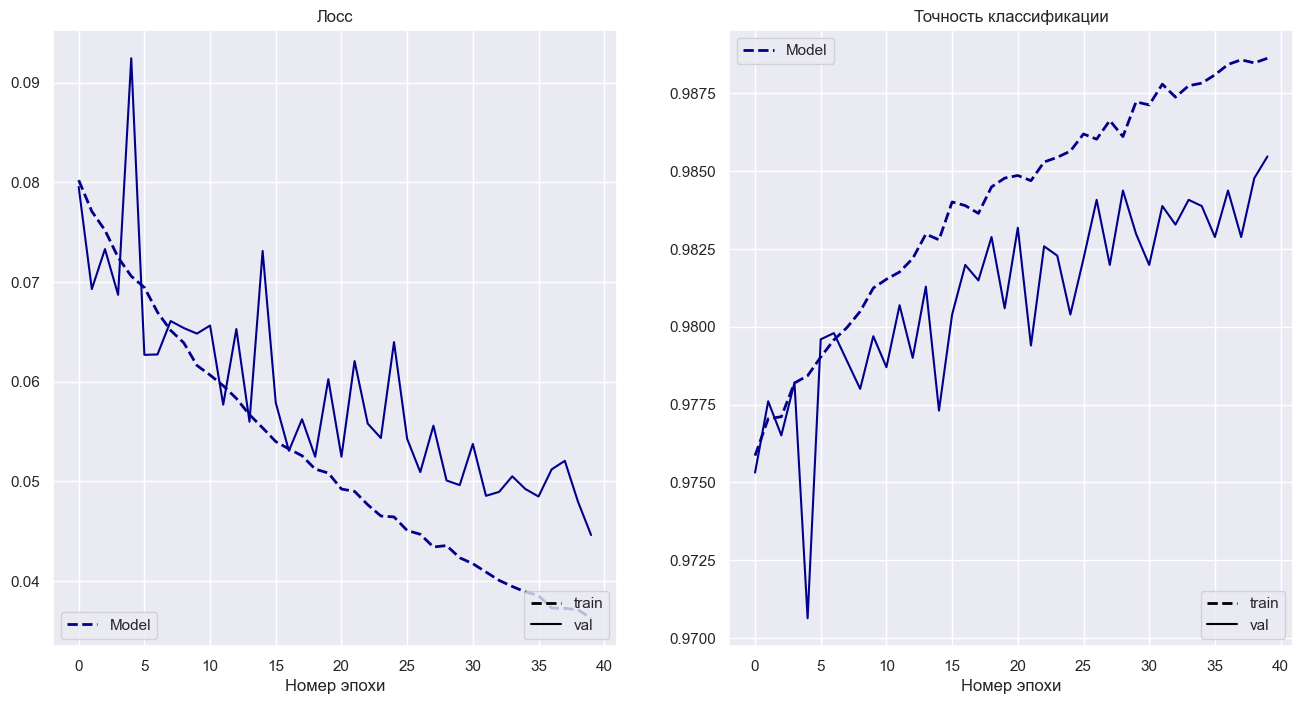

In [153]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(best_7.parameters())


histories_ker.append(train(best_7, criterion, optimizer, train_batch_gen, val_batch_gen))
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(best_7.state_dict(), "best_7.pth")

Эпоха 40 из 40, затраченное время 121.567 сек.
  лосс на обучении: 	0.054836
  лосс на валидации: 	0.058081
  точность на обучении: 		98.28 %
  точность на валидации: 		98.13 %


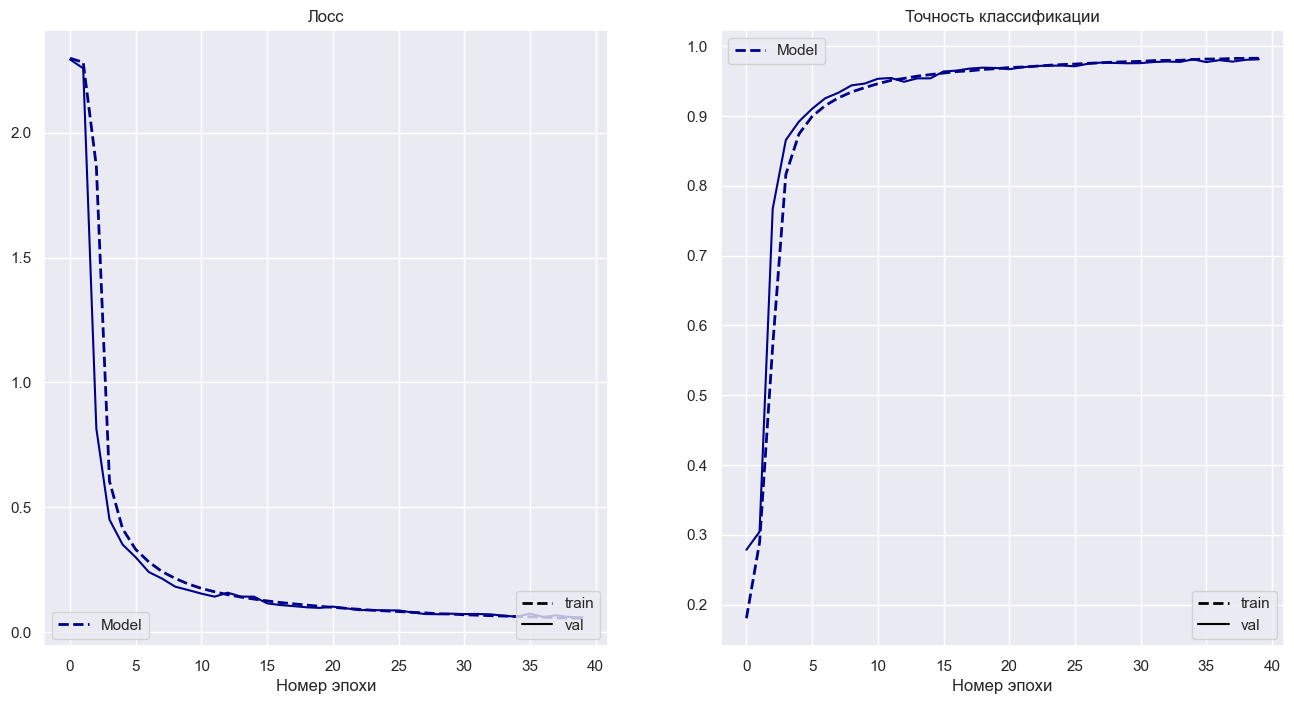

In [154]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(best_9.parameters())


histories_ker.append(train(best_9, criterion, optimizer, train_batch_gen, val_batch_gen))
# Сохраняем веса модели в файл, чтобы ее потом можно было подгрузить
torch.save(best_9.state_dict(), "best_9.pth")

Постройте график лосса и график accuracy, где сравниваются все модели этого эксперимента (на train и на val).

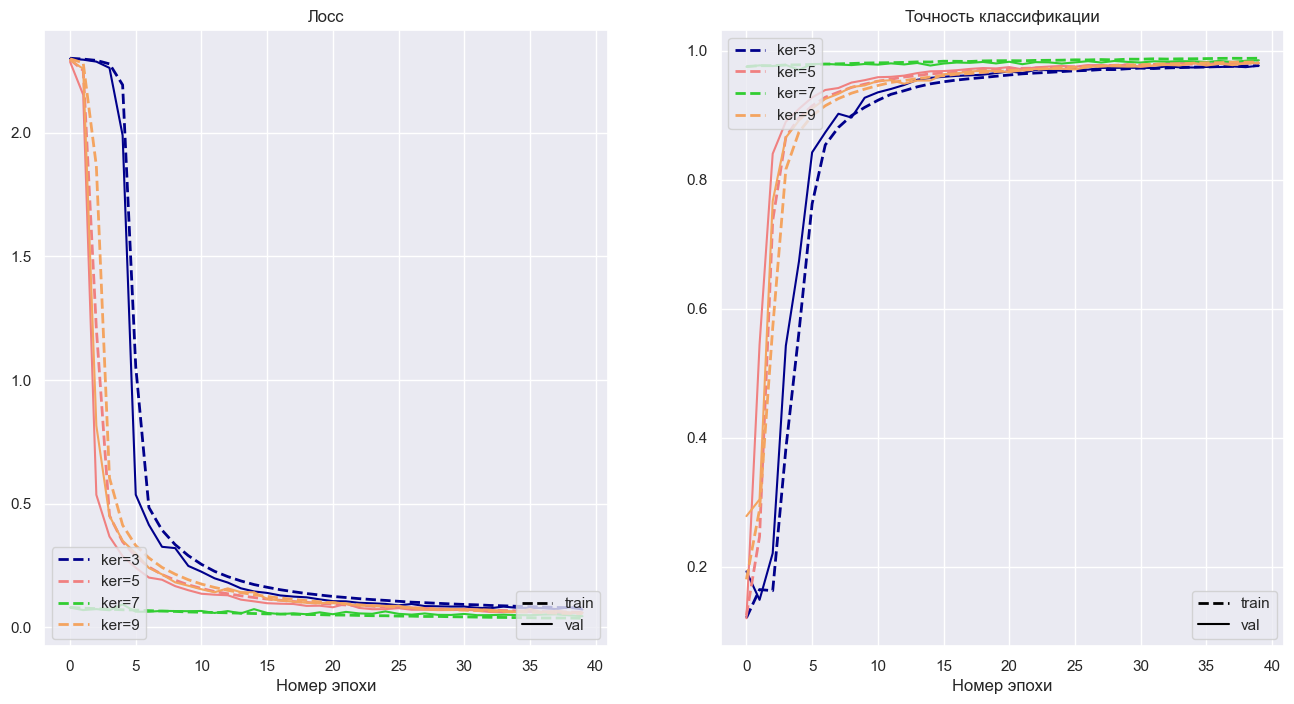

In [155]:
plot_histories(histories_ker, ['ker=3', 'ker=5', 'ker=7', 'ker=9'])

Сделайте вывод. Как размеры ядер влияют на качество и время обучения?

**Вывод по эксперименту:**

С величиной окна очень сильно возрастает время обучения
Но при этом видная четкая зависимость того, что accuracy увличивается с увеличением ядра

**4.** Выберите лучшую конфигурацию из всех по accuracy на валидации. Она должна быть не меньше 97%.

In [ ]:
...

Проведите еще один проход валидации выбранной моделью по всему датасету. В нем посчитайте точность по каждому классу и соберите информацию о неправильных предсказаниях. Равномерна ли точность по отношению к классам? Покажите 10-20 примеров, на которых нейросеть выдала неправильную метку. Что можно о них сказать?

In [ ]:
...

**Ответ:**

...

**5.** **Вывод по всей задаче:**

...

---
### Задача 2. Визуализиция сверточных слоев

Обучите модель, состоящую как минимум из 4 сверточных слоев, на датасете MNIST. **Количество выходных каналов в каждом сверточном слое должно быть равно 32**, а точность на тестовых данных должна достигать 97%. Для создания модели будет удобно использовать `torch.nn.Sequential`.


In [ ]:
...

Визуализируйте веса свертки на первом слое. Поскольку веса имеют размерность $(32, 1, K_1, K_2)$, т.к. входное изображение имеет один канал, вам необходимо отобразить 32 изображения (по количеству выходных каналов) фильтрами размера $K_1 \times K_2$.

*Совет.* Здесь и далее серии из 32 картинок визуализируйте в виде сетки с помощью `plt.subplots(4, 8, figsize=...)`. Не забывайте указывать параметр `cmap='gray'`.

In [ ]:
...

Какую функцию они могут нести? Для ответа на вопрос вспомните фильтры, рассмотренные на семинаре.

...

Для одного произвольного изображения из датасета MNIST визуализируйте выходы **всех слоев** нейросети, включая активацию и пуллинг, вплоть до операции `Flatten`, но не включая её. Каждый выход будет иметь размерность $(32, H_i, W_i)$. Таким образом, для каждого слоя необходимо создать $32$ изображения размером $H_i \times W_i$.

In [ ]:
...

Какие выводы можно сделать о том, как работает ваша сверточная сеть?

...

Визуализируйте, какие объекты, подаваемые на вход нейросети, в наибольшей степени активируют нейроны в сверточных слоях. Для этого оптимизируйте изображение, чтобы максимизировать выход нейрона.

Ниже представлен шаблон функции, которая находит изображение, максимально усиливающее реакцию нейрона. Пример можно посмотреть в <a href="https://thetahat.ru/files/ad/main/7/CV_complex_no_pause.pdf" target="_blank">презентации</a> с занятия.

In [ ]:
# При реализации запрещено пользоваться ИИ-инструментами.


def visualize_filter(
    model: nn.Module,
    layer_index: int,
    target_kernel: int,
    learning_rate: float = 1,
    steps: int = 10_000,
    image_size: int = 28,
    device: Union[str, torch.device] = "cpu",
) -> torch.Tensor:
    """Визуализирует фильтр сверточного слоя нейронной сети путем оптимизации
    входного изображения, которое максимизирует активацию заданного фильтра.

    Параметры:
        model (nn.Module): Модель нейронной сети, содержащая целевой сверточный слой.
        layer_index (int): Индекс целевого сверточного слоя в модели (по порядку в model.children()).
        target_kernel (int): Индекс фильтра в целевом слое для визуализации.
        learning_rate (float, optional): Скорость обучения для оптимизатора. По умолчанию 1.
        steps (int, optional): Количество шагов оптимизации. По умолчанию 10000.
        image_size (int, optional): Размер стороны квадратного входного изображения. По умолчанию 28.
        device (str|torch.device, optional): Устройство для вычислений ('cpu' или 'cuda'). По умолчанию "cpu".

    Возвращает:
        torch.Tensor: Оптимизированное изображение (тензор формы [1, C, H, W]),
                     которое максимизирует активацию целевого фильтра.
    """

    model.eval().to(device)  # Переводим модель в режим оценки

    # Инициализируем изображение случайным шумом
    input_img = torch.randn(..., requires_grad=True, device=device)
    # Обратите внимание, что в данном случае мы оптимизируем не модель, а входную картинку
    optimizer = optim.SGD(...)

    # Функция потерь: максимизируем активацию нужного ядра свертки
    for step in range(steps):

        # Пропускаем изображение через модель
        output = ...  # Выход заданного сверточного слоя
        loss = ...  # Минимизируемая функция

        # Обратное распространение
        ...

        # Ограничиваем значения пикселей в разумных пределах
        input_img.data = torch.clamp(input_img.data, -1, 1)

        # Логируем лосс
        if step % 500 == 0:
            print(f"Step {step}/{steps}, Loss: {loss.item():.4f}")

    # Преобразуем оптимизированное изображение
    img = ...

    return img

In [ ]:
...

Сделайте выводы о том, как с глубиной слоя меняется способность нейрона видеть различные паттерны на изображении.

...

---
### Задача 3. Перенос стиля

*Данную задачу, возможно, проще сделать в Google Colab.*

В данной задаче вы потренируетесь в работе с картинками и составлением промптов. Используя код с <a href="https://thetahat.ru/courses/ad/main/7/cv_complex_examples" target="_blank">семинара</a>, проведите перенос стиля на хотя бы 4 своих примерах.

> Заметьте, что в примерах с семинара в качестве картинок стиля и контента использовались картинки среднего разрешения. Если возникают проблемы, например:
> * оптимизация останавливается на 0-й эпохе и не создает картинку;
> * loss в какой-то момент стал nan;
> * нехватка RAM;
>
> то либо уменьшите разрешение ваших картинок, либо попробуйте картинку полегче.

In [ ]:
...

Для тех же пар изображений контест-стиль попытайтесь сгенерировать картинку с таким контекстом и стилем с помощью диффузионной модели, рассмотренной на семинаре, задав нужный промпт.

In [ ]:
...

**Вывод:**

...

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД